In [23]:
from autoreduce import *
import numpy as np

?

$ \dot{x} = f(x,\Theta) \quad \\ \quad
y = Cx \quad \\ \quad
x =
\begin{bmatrix}
P \\
C_1 \\
T \\
R \\
C_2 \\
X
\end{bmatrix}
\quad \\ \quad
\Theta =
\begin{bmatrix}
k_{bp} \\
k_{up} \\
k_{tx} \\
k_{br} \\
k_{ur} \\
k_{tl} \\
d_T \\
d_X \\
G
\end{bmatrix}
\quad \\ \quad
y = X $

$
\begin{aligned}
\dot{P} &= (k_{up}+k_{tx})C_1 - k_{bp}GP \\
\dot{C}_1 &= k_{bp}GP - (k_{up}+k_{tx})C_1 \\
\dot{T} &= k_{tx}C_1 + (k_{ur}+k_{tl})C_2 - k_{br}TR - d_TT \\
\dot{R} &= (k_{ur}+k_{tl})C_2 - k_{br}TR \\
\dot{C}_2 &= k_{br}TR - (k_{ur}+k_{tl})C_2 \\
\dot{X} &= k_{tl}C_2 - d_XX
\end{aligned}
$

Used the previous michaelis-mention example as skeleton code, but adjusted it to fit the equations above, changed the varaible we care about to x[5], (X protein). Also adjusted the timepoints_ode to np.linespace(0,24,100), referencing https://github.com/ayush9pandey/AutoReduce/blob/main/examples/gene%20expression%20analysis.ipynb

In [24]:
from autoreduce import *
import numpy as np
import matplotlib.pyplot as plt

# Full protein expression model
n = 6
nouts = 1

# parameters:
# P[0] = kbp
# P[1] = kup
# P[2] = ktx
# P[3] = kbr
# P[4] = kur
# P[5] = ktl
# P[6] = dT
# P[7] = dX
# P[8] = G

P = np.zeros(9)

P[0] = 10     # kbp
P[1] = 10     # kup
P[2] = 1      # ktx
P[3] = 10     # kbr
P[4] = 10     # kur
P[5] = 1      # ktl
P[6] = 0.1    # dT
P[7] = 0.1    # dX
P[8] = 1      # G

params_values = P.copy()
timepoints_ode = np.linspace(0, 150, 100)

# x[0] = P_free
# x[1] = C1
# x[2] = T
# x[3] = R_free
# x[4] = C2
# x[5] = X protein

x_init = np.zeros(n)
x_init[0] = 0      # P_free
x_init[1] = 100    # C1
x_init[2] = 400    # T
x_init[3] = 100    # R_free
x_init[4] = 0      # C2
x_init[5] = 20     # X

error_tol = 100
nstates_tol = 2

x, f, P = load_ODE_model(n, len(params_values))
params = P

f[0] = (P[1] + P[2])*x[1] - P[0]*P[8]*x[0]
f[1] = P[0]*P[8]*x[0] - (P[1] + P[2])*x[1]
f[2] = P[2]*x[1] + (P[4] + P[5])*x[4] - P[3]*x[2]*x[3] - P[6]*x[2]
f[3] = (P[4] + P[5])*x[4] - P[3]*x[2]*x[3]
f[4] = P[3]*x[2]*x[3] - (P[4] + P[5])*x[4]
f[5] = P[5]*x[4] - P[7]*x[5]

C = np.zeros((nouts, len(x)), dtype=int)
C[0][5] = 1
C = C.tolist()

sys = System(
    x,
    f,
    params=params,
    C=C,
    params_values=params_values,
    x_init=x_init
)

In [25]:
sys.x

[x0, x1, x2, x3, x4, x5]

In [26]:
# commented out the heatmap because seaborn wasn't installed
from autoreduce.utils import get_SSM
timepoints_ssm = np.linspace(0,60,10)
sys_ssm = get_SSM(sys, timepoints_ssm)
Ss = sys_ssm.compute_SSM(normalize = True) # len(timepoints) x len(params) x len(states)
out_Ss = []
for i in range(len(params)):
    out_Ss.append((np.array(C)@(Ss[:,i,:].T)))
out_Ss = np.reshape(np.array(out_Ss), (len(timepoints_ssm), len(params), nouts))


SSM Progress: |██████████████████████████████████████████████████| 100.0% Complete


C:\Users\angel\autoreduce\autoreduce\local_sensitivity.py:257: RuntimeWarning: invalid value encountered in divide
  SSM_normalized[:, j, i] = np.divide(


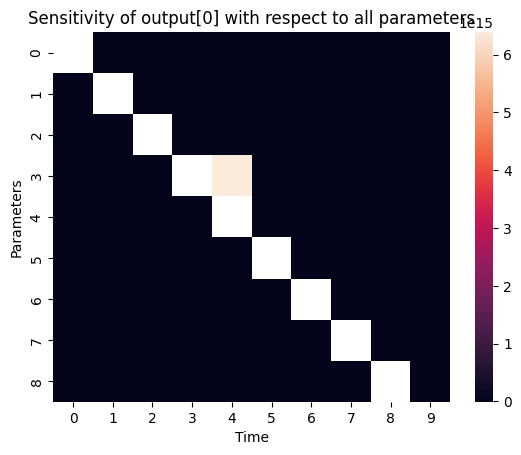

In [27]:
try:
    import seaborn as sn
    for j in range(nouts):
        sn.heatmap(out_Ss[:,:,j].T)
        plt.xlabel('Time')
        plt.ylabel('Parameters')
        plt.title('Sensitivity of output[{0}] with respect to all parameters'.format(j))
        plt.show()
except:
    print('Plotting libraries missing.')

In [28]:
from autoreduce.utils import get_reducible
timepoints_ssm = np.linspace(0,60,10)
timepoints_ode = np.linspace(0, 100, 100)
sys_reduce = get_reducible(sys, timepoints_ode, timepoints_ssm)
#results = sys_reduce.reduce_simple(skip_numerical_computation = True,skip_error_computation = True, skip_robustness_computation = True)
results = sys_reduce.reduce_simple()

C:\Users\angel\autoreduce\autoreduce\model_reduction.py:1215: UserWarning: Solve time-scale separation failed. Check model consistency.
  warnings.warn(


Could not find solution for: x1 from 0
Could not find solution for: x4 from -x4*(P4 + P5) + P6*x4*(P4 + P5)*(P2*x1 + P4*x4 + P5*x4)/(P2*x1*(P6 + P6*x4*(P4 + P5)/(P2*x1)))
Could not find solution for: x1 from 0
Could not find solution for: x4 from -x4*(P4 + P5) + P6*x4*(P4 + P5)*(P2*x1 + P4*x4 + P5*x4)/(P2*x1*(P6 + P6*x4*(P4 + P5)/(P2*x1)))
Could not find solution for: x1 from 0
Could not find solution for: x4 from -x4*(P4 + P5) + P6*x4*(P4 + P5)*(P2*x1 + P4*x4 + P5*x4)/(P2*x1*(P6 + P6*x4*(P4 + P5)/(P2*x1)))
Could not find solution for: x1 from 0
Could not find solution for: x4 from -x4*(P4 + P5) + P6*x4*(P4 + P5)*(P2*x1 + P4*x4 + P5*x4)/(P2*x1*(P6 + P6*x4*(P4 + P5)/(P2*x1)))
Did not work to retain: [x5] because either a collapsed state-variables appears
 in the reduced model or a solution is not possible.


C:\Users\angel\autoreduce\autoreduce\model_reduction.py:470: UserWarning: Solve time-scale separation failed.Check model consistency.
  warnings.warn(


Could not find solution for: x4 from -x4*(P4 + P5) + P6*x4*(P1 + P2)*(P4 + P5)*(P0*P2*P8*x0 + P1*P4*x4 + P1*P5*x4 + P2*P4*x4 + P2*P5*x4)/(P0*P2*P8*x0*(P1*P6 + P2*P6 + P1*P6*x4*(P1 + P2)*(P4 + P5)/(P0*P2*P8*x0) + P6*x4*(P1 + P2)*(P4 + P5)/(P0*P8*x0)))
Could not find solution for: x4 from -x4*(P4 + P5) + P6*x4*(P1 + P2)*(P4 + P5)*(P0*P2*P8*x0 + P1*P4*x4 + P1*P5*x4 + P2*P4*x4 + P2*P5*x4)/(P0*P2*P8*x0*(P1*P6 + P2*P6 + P1*P6*x4*(P1 + P2)*(P4 + P5)/(P0*P2*P8*x0) + P6*x4*(P1 + P2)*(P4 + P5)/(P0*P8*x0)))
Could not find solution for: x4 from -x4*(P4 + P5) + P6*x4*(P1 + P2)*(P4 + P5)*(P0*P2*P8*x0 + P1*P4*x4 + P1*P5*x4 + P2*P4*x4 + P2*P5*x4)/(P0*P2*P8*x0*(P1*P6 + P2*P6 + P1*P6*x4*(P1 + P2)*(P4 + P5)/(P0*P2*P8*x0) + P6*x4*(P1 + P2)*(P4 + P5)/(P0*P8*x0)))
Could not find solution for: x4 from -x4*(P4 + P5) + P6*x4*(P1 + P2)*(P4 + P5)*(P0*P2*P8*x0 + P1*P4*x4 + P1*P5*x4 + P2*P4*x4 + P2*P5*x4)/(P0*P2*P8*x0*(P1*P6 + P2*P6 + P1*P6*x4*(P1 + P2)*(P4 + P5)/(P0*P2*P8*x0) + P6*x4*(P1 + P2)*(P4 + P5)/(P0*P8*x0

C:\Users\angel\autoreduce\autoreduce\local_sensitivity.py:235: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  sol = odeint(sens_func_ode, S0, timepoints, tfirst=True)


SSM Progress: |██████████████████████████████████████████████████| 100.0% Complete
Successful solution obtained with states: [x0, x4, x5]!
SSM Progress: |██████████████████████████████████████████████████| 100.0% Complete
SSM Progress: |██████████████████████████████████████████████████| 100.0% Complete
Could not find solution for: x4 from 0
Could not find solution for: x4 from 0
Could not find solution for: x4 from 0
Could not find solution for: x4 from 0
Did not work to retain: [x1, x2, x5] because either a collapsed state-variables appears
 in the reduced model or a solution is not possible.
Successful solution obtained with states: [x1, x3, x5]!
SSM Progress: |██████████████████████████████████████████████████| 100.0% Complete
SSM Progress: |██████████████████████████████████████████████████| 100.0% Complete
Successful solution obtained with states: [x1, x4, x5]!
SSM Progress: |██████████████████████████████████████████████████| 100.0% Complete
SSM Progress: |██████████████████████

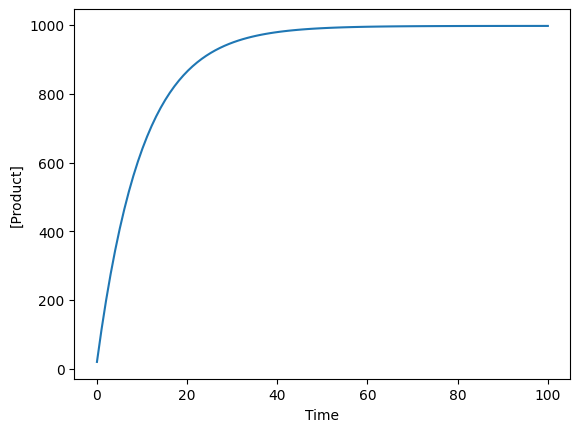

In [29]:
from autoreduce.utils import get_ODE
sys_ode = get_ODE(sys, timepoints_ode)
sol = sys_ode.solve_system().T
#try:
import matplotlib.pyplot as plt
plt.plot(timepoints_ode, np.transpose(np.array(C)@sol))
plt.xlabel('Time')
plt.ylabel('[Product]')
plt.show()
#except:
#    print('Plotting libraries missing.')

All the reduced models in contained in the dictionary named results. extracted all the models in a list called reduced models

In [30]:
results

{<autoreduce.system.System at 0x2017ef3e110>: [np.float64(9178.551185441846),
  array([7.17935039e+14, 7.17935039e+14, 7.17935039e+14, 7.17935039e+14,
         7.17935039e+14, 7.17935039e+14,            inf,            inf,
                    inf]),
  np.float64(0.0)],
 <autoreduce.system.System at 0x20134429120>: [np.float64(9178.551185441846),
  array([7.17935039e+14, 7.17935039e+14, 7.17935039e+14, 7.17935039e+14,
         7.17935039e+14, 7.17935039e+14, 6.81234882e+09, 6.81234882e+09,
         6.81234879e+09]),
  np.float64(3.043964452274229e-13)],
 <autoreduce.system.System at 0x20131a4fa60>: [np.float64(8354993.648997664),
  array([7.17935039e+14, 7.17935039e+14, 7.17935039e+14, 7.17935039e+14,
         7.17935039e+14, 7.17935039e+14, 2.48861592e+30, 2.48861592e+30,
         2.48861592e+30]),
  np.float64(2.797737754443762e-24)],
 <autoreduce.system.System at 0x2013452f2b0>: [np.float64(9178.551185441846),
  array([7.17935039e+14, 7.17935039e+14, 7.17935039e+14, 7.17935039e+14,


In [31]:
list(results.keys())[0].x

[x0, x3, x5]

In [32]:
reduced_models = list(results.keys())

#automatically names them
for i, model in enumerate(reduced_models):
    globals()[f"reduced_model_{i+1}"] = model

Proceeded to plot it using plot.ly. Asked Claude from VScode to code using plot.ly and color code it + sort the legend based off MAE (mean squared error)

In [33]:
from autoreduce.utils import get_ODE
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt

# Solve original full model
sys_ode = get_ODE(sys, timepoints_ode)
orig_sol = sys_ode.solve_system().T

# Original output: y = Cx
orig_output = np.ravel(np.array(C) @ orig_sol)

reduced_results = []

for i, model in enumerate(reduced_models):
    try:
        red_ode = get_ODE(model, timepoints_ode)
        red_sol = red_ode.solve_system().T

        # reduced output
        red_C = np.array(model.C)
        red_output = np.ravel(red_C @ red_sol)

        # compare to original
        mae = np.mean(np.abs(orig_output - red_output))

        reduced_results.append({
            "name": f"Reduced model {i+1}: {model.x}",
            "model": model,
            "output": red_output,
            "mae": mae
        })

    except Exception as e:
        print(f"Reduced model {i+1} failed: {model.x}")
        print(e)

# Sort best to worst
reduced_results = sorted(reduced_results, key=lambda d: d["mae"])

# Color by error
mae_values = [r["mae"] for r in reduced_results]

norm = plt.Normalize(min(mae_values), max(mae_values))
cmap = plt.cm.get_cmap("RdYlGn_r")  # green = closer, red = worse

fig = go.Figure()

# Original model as dotted black reference
fig.add_trace(
    go.Scatter(
        x=timepoints_ode,
        y=orig_output,
        mode="lines",
        name="Original full model",
        line=dict(color="black", dash="dot", width=4)
    )
)

# Add reduced models in sorted order
for r in reduced_results:
    rgba = cmap(norm(r["mae"]))
    color = (
        f"rgb({int(rgba[0]*255)},"
        f"{int(rgba[1]*255)},"
        f"{int(rgba[2]*255)})"
    )

    fig.add_trace(
        go.Scatter(
            x=timepoints_ode,
            y=r["output"],
            mode="lines",
            name=f"{r['name']} | MAE={r['mae']:.3g}",
            line=dict(color=color, width=2)
        )
    )

fig.update_layout(
    title="Original vs Reduced Protein Expression Models",
    xaxis_title="Time",
    yaxis_title="Protein X",
    legend_title="Models sorted by closeness",
    template="plotly_white",
    width=1000,
    height=650
)

fig.show()

C:\Users\angel\AppData\Local\Temp\ipykernel_26724\4062284274.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("RdYlGn_r")  # green = closer, red = worse


When you look at the plot above, reduced models #17, 12, & 15 are the cloestest to the orignal ODE model (they all have a MAE of < 100). I decided to print it down in latex below.

In [34]:
#here's the original
sys.f

[-P0*P8*x0 + x1*(P1 + P2),
 P0*P8*x0 - x1*(P1 + P2),
 P2*x1 - P3*x2*x3 - P6*x2 + x4*(P4 + P5),
 -P3*x2*x3 + x4*(P4 + P5),
 P3*x2*x3 - x4*(P4 + P5),
 P5*x4 - P7*x5]

In [35]:
#here's the orignal in LaTeX
from IPython.display import display, Math
from sympy import latex

display(Math(latex(sys.f)))

<IPython.core.display.Math object>

In [36]:
#exploratory analysis of the reduced models

print(reduced_model_17.x)
print(reduced_model_12.x)
print(reduced_model_15.x)


[x1, x2, x3, x4, x5]
[x1, x3, x4, x5]
[x0, x1, x3, x4, x5]


In [37]:
#reduced models in LaTex

display(Math(r"\text{Original System: } " + latex(sys.f)))
display(Math(r"\text{17: }" + latex(reduced_model_17.f)))
display(Math(r"\text{12: }" + latex(reduced_model_12.f)))
display(Math(r"\text{15: }" + latex(reduced_model_15.f)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

All Code below this was copied from Michaelis-Menten Example, you must fully run reduce.simple() w/o paramters. 

In [38]:
err = results[list(results.keys())[0]][0]
Se = results[list(results.keys())[0]][1]
weighted_se = 0
for p, Se_i in zip(params_values, Se):
    weighted_se += p*Se_i

In [39]:
d_R = weighted_se/err
d_R

np.float64(inf)

In [40]:
w1 = 1
w2 = 1e-3
r = w1*err + w2*d_R
r

np.float64(inf)